# CSC 5800 - Intelligent Systems: Algorithms and Tools
## Project: Hybrid Network Intrusion Detection System
### Notebook 4: Final Demo

| | |
|---|---|
| **Student** | Fahad Qaseem Khawar |
| **Instructor** | Dr. Suzan Arslanturk |
| **Semester** | Winter 2026 |
| **Dataset** | UNSW-NB15 (257,673 records, 10 attack categories) |
| **Best Model** | XGBoost — F1: 0.9866, ROC-AUC: 0.9989 |

---

### How to run this notebook
1. Connect to **T4 GPU** runtime (Runtime > Change runtime type)
2. Click **Runtime > Run all**
3. All outputs, plots, and tables will render automatically

No training is performed. All models are loaded from Google Drive.

---

### What this notebook demonstrates
- Section 1: Project overview and dataset summary
- Section 2: EDA figures from Notebook 2
- Section 3: Stage 1 — Anomaly Detection (Isolation Forest)
- Section 4: Stage 2 — Supervised Classification (RF, XGBoost, LightGBM, SVM)
- Section 5: Multi-class Attack Classification (fixed)
- Section 6: K-Means Clustering results
- Section 7: Association Rule Mining
- Section 8: Full model comparison and ROC curves
- Section 9: Live prediction demo on new samples

## 0. Setup

In [5]:
import warnings, logging, os, sys
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)
os.environ['PYTHONWARNINGS'] = 'ignore'
stderr_backup = sys.stderr
sys.stderr = open(os.devnull, 'w')

from google.colab import drive
drive.mount('/content/drive')
sys.stderr = stderr_backup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import joblib
import json
import time

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

!pip install xgboost lightgbm mlxtend -q 2>/dev/null
import xgboost as xgb
import lightgbm as lgb
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

BASE  = '/content/drive/MyDrive/CSC5800_NIDS_Project'
PROC  = f'{BASE}/data/processed'
FIGS  = f'{BASE}/figures'
MDLS  = f'{BASE}/models'
RES   = f'{BASE}/results'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print('Setup complete. Loading data and models...')

Mounted at /content/drive
Setup complete. Loading data and models...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# Load data
train_df  = pd.read_csv(f'{PROC}/train_processed.csv')
test_df   = pd.read_csv(f'{PROC}/test_processed.csv')
features  = pd.read_csv(f'{PROC}/selected_features.csv', header=None)[0].tolist()
le_cat    = joblib.load(f'{PROC}/label_encoder_cat.pkl')

X_train   = train_df[features].values
y_train   = train_df['label'].astype(int).values
X_test    = test_df[features].values
y_test    = test_df['label'].astype(int).values

# Load models
iso_forest = joblib.load(f'{MDLS}/isolation_forest.pkl')
rf         = joblib.load(f'{MDLS}/random_forest.pkl')
xgb_clf    = joblib.load(f'{MDLS}/xgboost.pkl')
lgb_clf    = joblib.load(f'{MDLS}/lightgbm.pkl')
svm_clf    = joblib.load(f'{MDLS}/svm.pkl')
km_final   = joblib.load(f'{MDLS}/kmeans.pkl')

print(f'Data loaded    — Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Models loaded  — IF, RF, XGBoost, LightGBM, SVM, KMeans')
print(f'Attack classes — {list(le_cat.classes_)}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Data loaded    — Train: (263476, 30) | Test: (51535, 30)
Models loaded  — IF, RF, XGBoost, LightGBM, SVM, KMeans
Attack classes — ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Section 1: Project & Dataset Overview

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

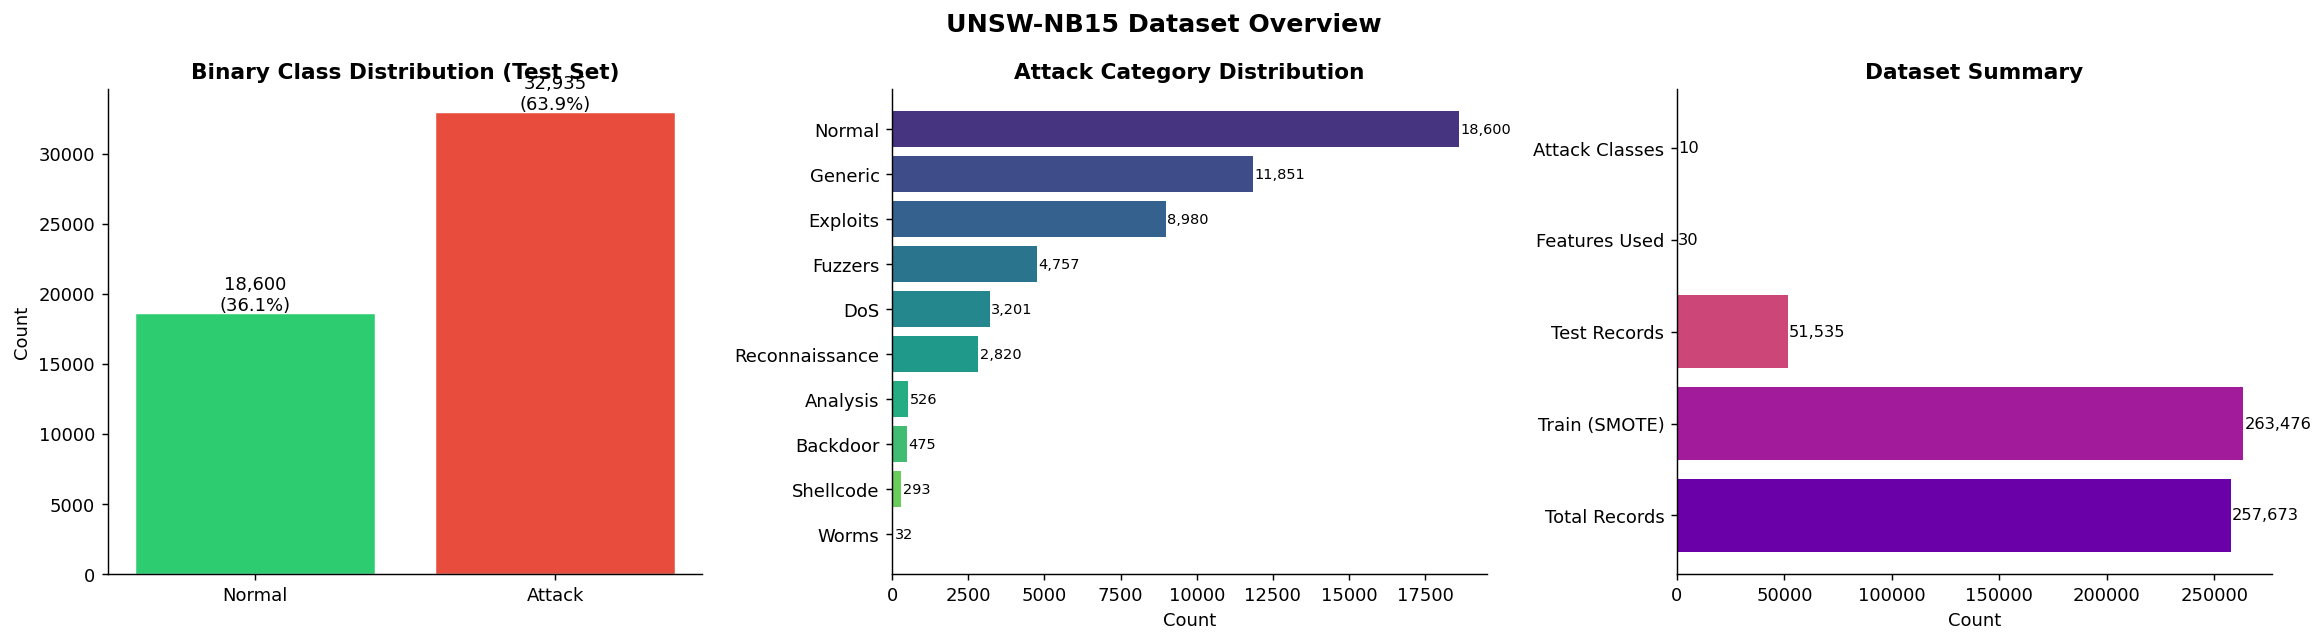

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
attack_counts = test_df.copy()
attack_counts['attack_cat'] = attack_counts['label_multi'].map(
    {i: c for i, c in enumerate(le_cat.classes_)}
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Binary distribution
lc = pd.Series(y_test).value_counts().sort_index()
axes[0].bar(['Normal', 'Attack'], lc.values, color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Binary Class Distribution (Test Set)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(lc.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(y_test)*100:.1f}%)', ha='center', fontsize=10)

# Attack categories
cat_counts = attack_counts['attack_cat'].value_counts()
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(cat_counts)))
axes[1].barh(cat_counts.index, cat_counts.values, color=colors)
axes[1].set_title('Attack Category Distribution', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# Feature count summary
summary = {
    'Total Records': 257673,
    'Train (SMOTE)': len(X_train),
    'Test Records': len(X_test),
    'Features Used': len(features),
    'Attack Classes': len(le_cat.classes_)
}
axes[2].barh(list(summary.keys()), list(summary.values()),
             color=plt.cm.plasma(np.linspace(0.2, 0.8, len(summary))))
axes[2].set_title('Dataset Summary', fontweight='bold')
axes[2].set_xlabel('Count')
for i, v in enumerate(summary.values()):
    axes[2].text(v + 500, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('UNSW-NB15 Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2: EDA Highlights

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

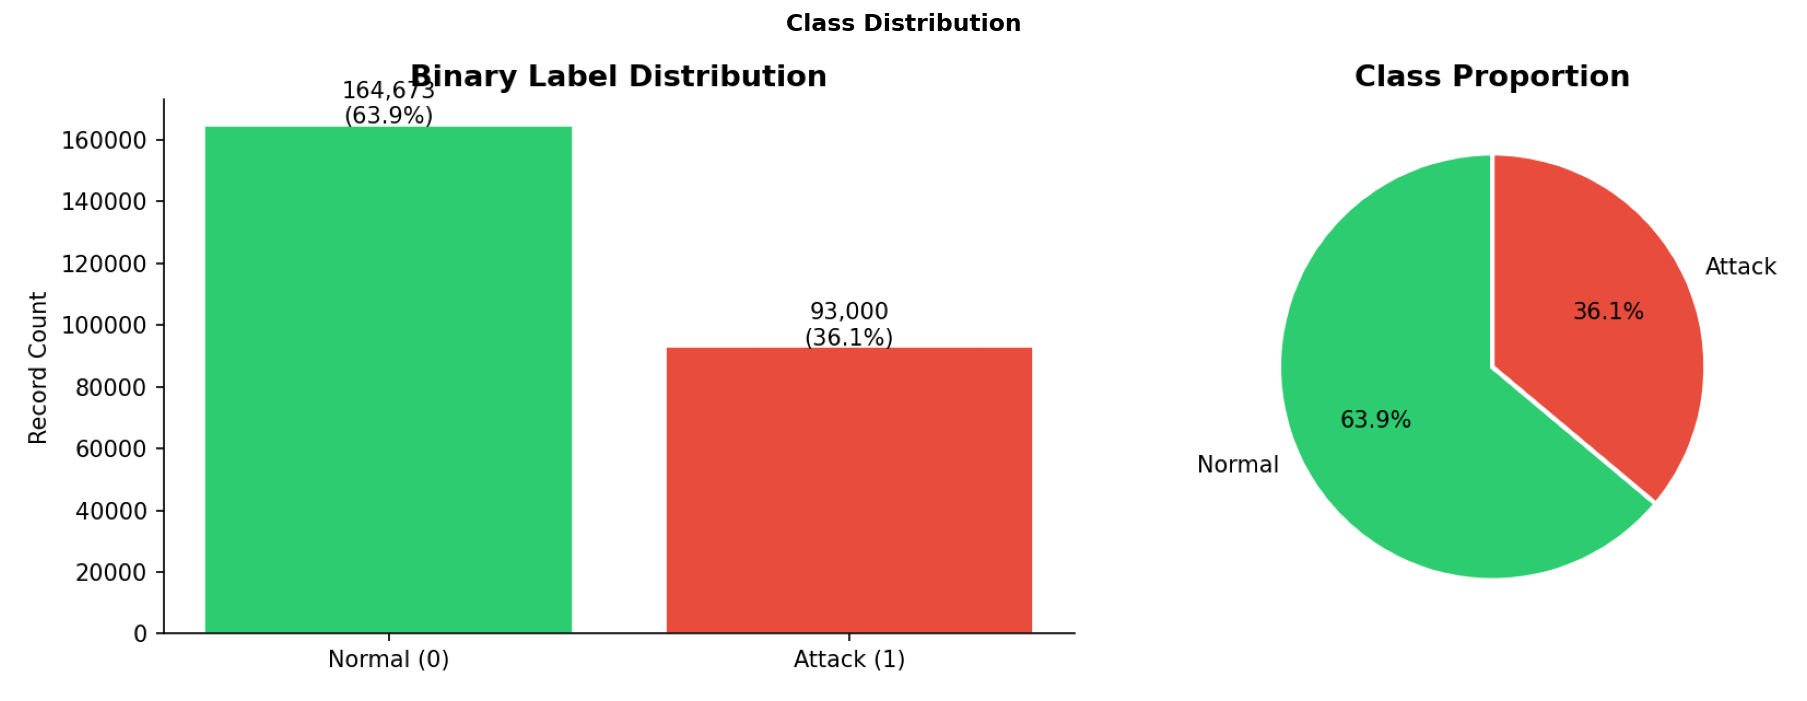

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

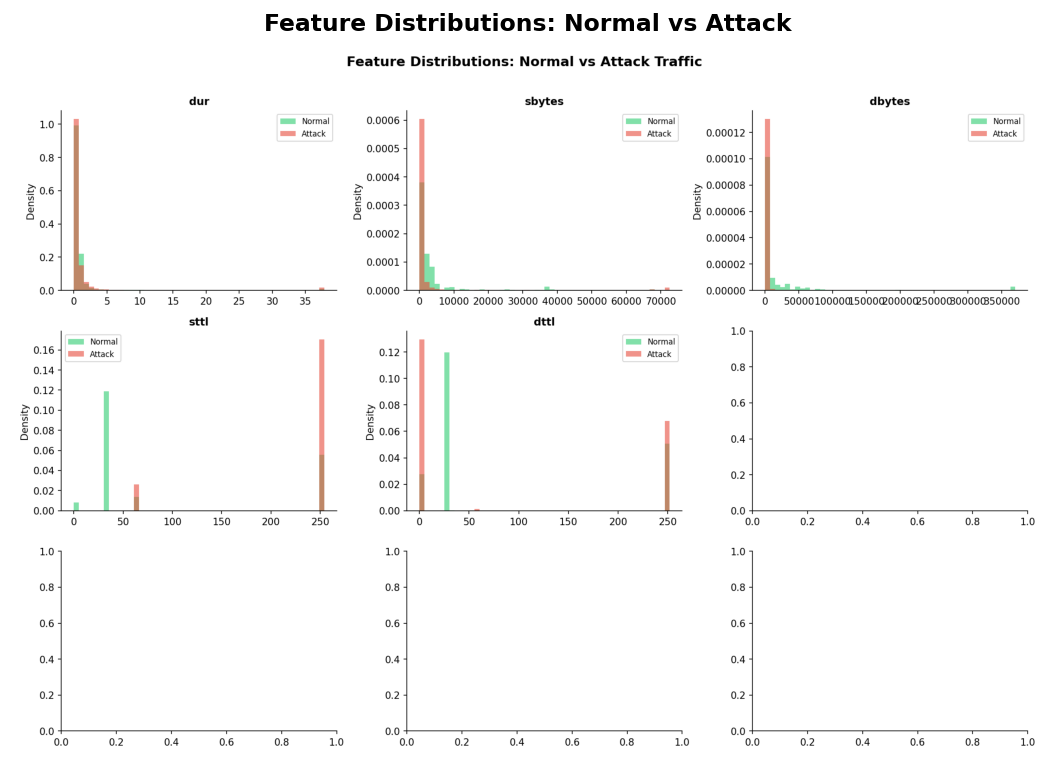

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

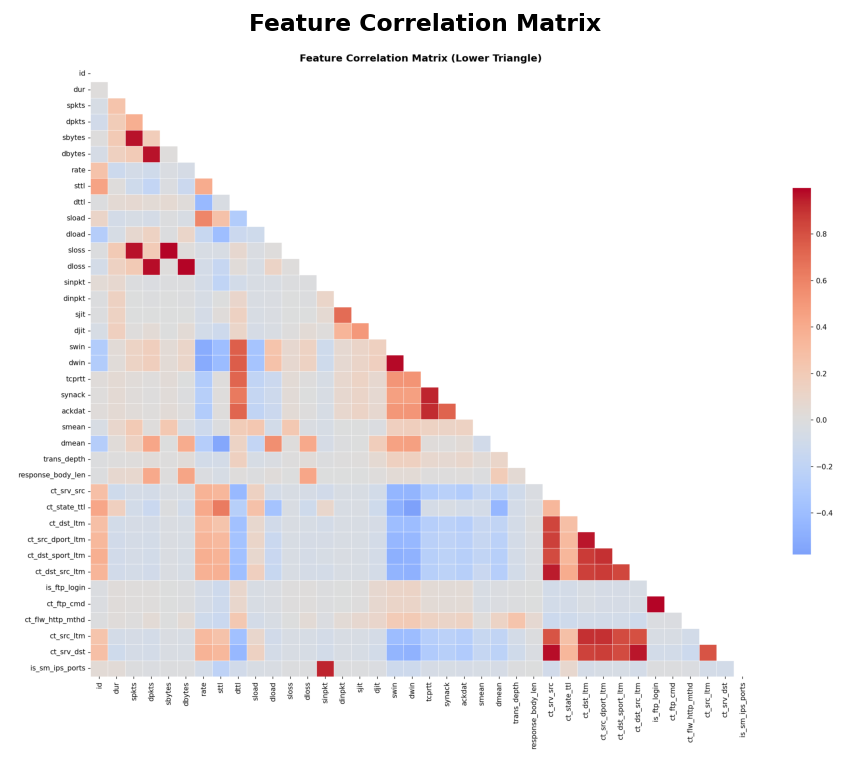

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

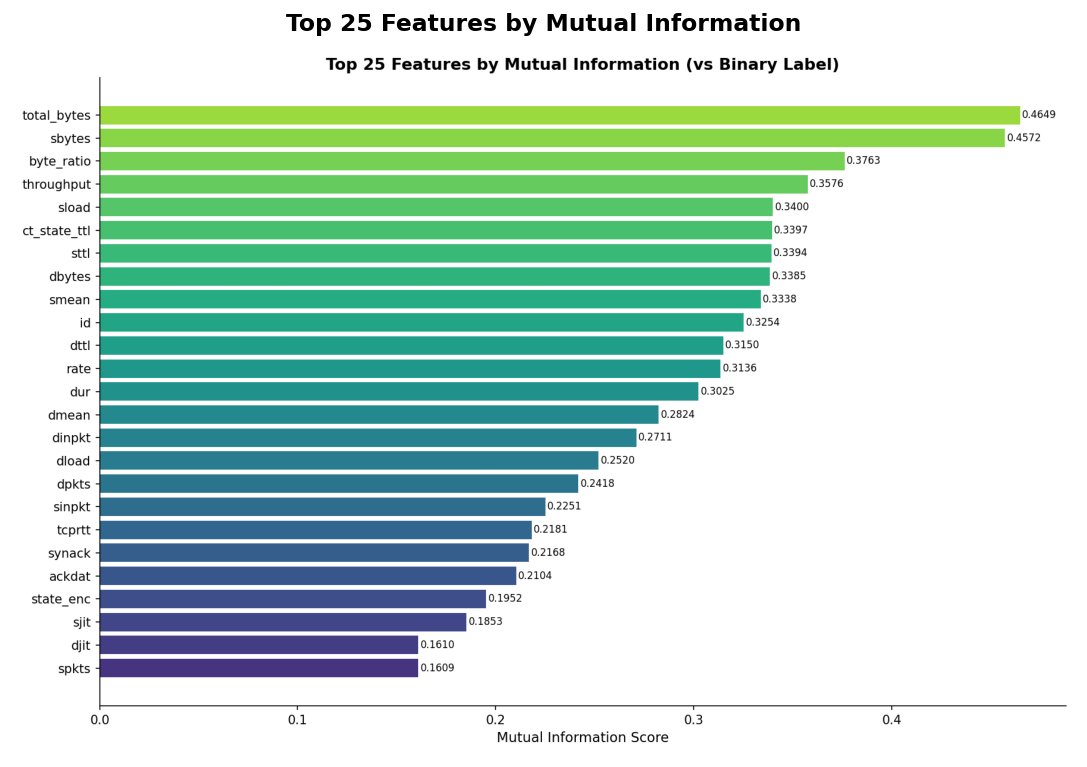

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

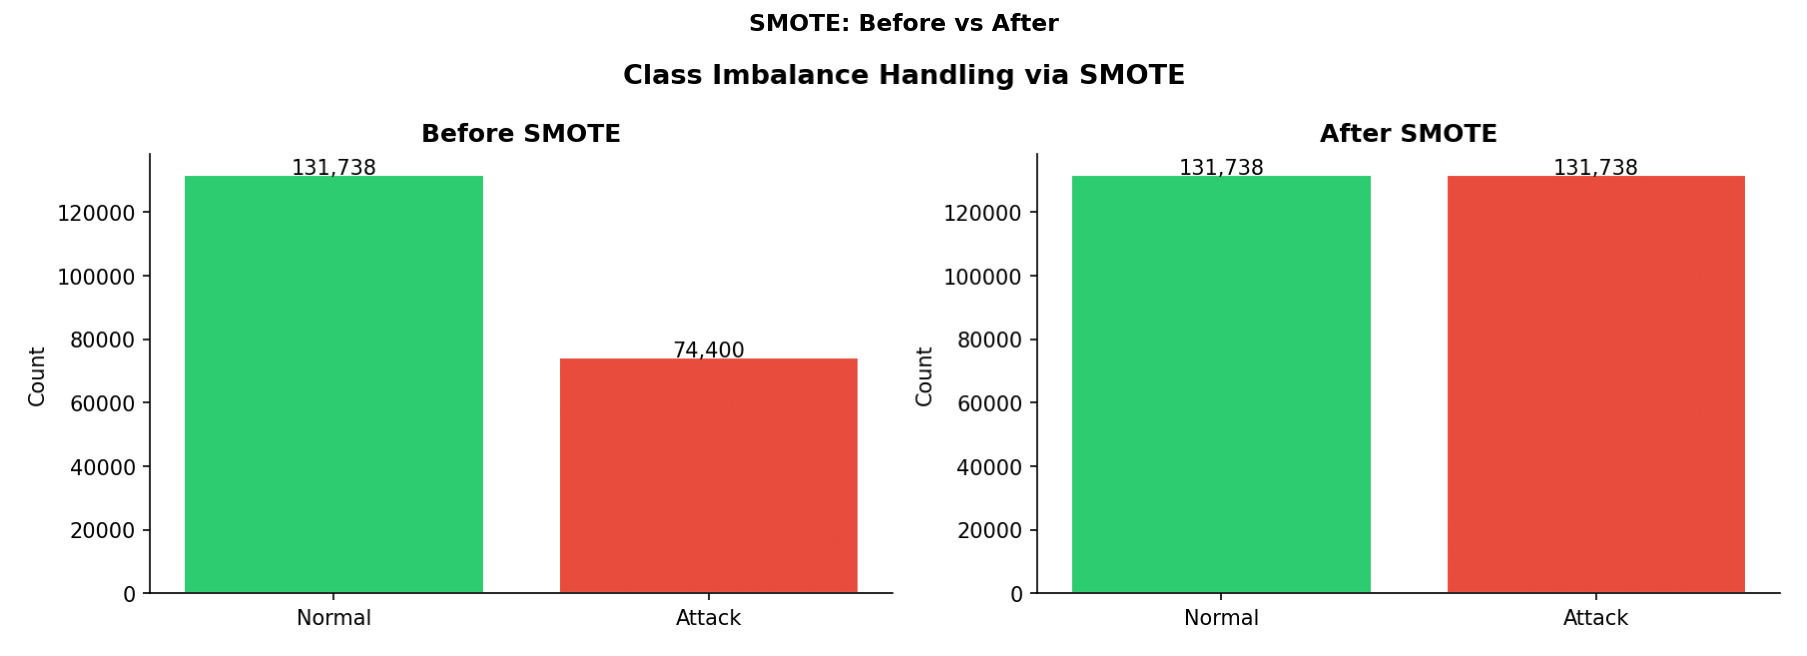

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
eda_figs = [
    ('01_binary_class_dist.png',    'Class Distribution'),
    ('03_feature_distributions.png','Feature Distributions: Normal vs Attack'),
    ('04_correlation_heatmap.png',  'Feature Correlation Matrix'),
    ('09_mutual_information.png',   'Top 25 Features by Mutual Information'),
    ('10_smote_comparison.png',     'SMOTE: Before vs After'),
]

for fname, title in eda_figs:
    fpath = f'{FIGS}/{fname}'
    if os.path.exists(fpath):
        img = mpimg.imread(fpath)
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f'Figure not found: {fname}')

---
## Section 3: Stage 1 — Anomaly Detection (Isolation Forest)

In [9]:
iso_preds_raw = iso_forest.predict(X_test)
iso_preds     = np.where(iso_preds_raw == -1, 1, 0)
iso_scores    = -iso_forest.score_samples(X_test)
flagged_mask  = iso_preds == 1

print('=== Stage 1: Isolation Forest (Anomaly Detection) ===')
print(classification_report(y_test, iso_preds, target_names=['Normal','Attack']))
print(f'ROC-AUC         : {roc_auc_score(y_test, iso_scores):.4f}')
print(f'Records flagged : {flagged_mask.sum():,} / {len(y_test):,} ({flagged_mask.mean()*100:.1f}%)')
print(f'True attacks    : {y_test[flagged_mask].sum():,}')
print(f'False positives : {(y_test[flagged_mask]==0).sum():,}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Stage 1: Isolation Forest (Anomaly Detection) ===
              precision    recall  f1-score   support

      Normal       0.49      0.84      0.62     18600
      Attack       0.85      0.50      0.63     32935

    accuracy                           0.62     51535
   macro avg       0.67      0.67      0.62     51535
weighted avg       0.72      0.62      0.62     51535

ROC-AUC         : 0.7926
Records flagged : 19,402 / 51,535 (37.6%)
True attacks    : 16,436
False positives : 2,966


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

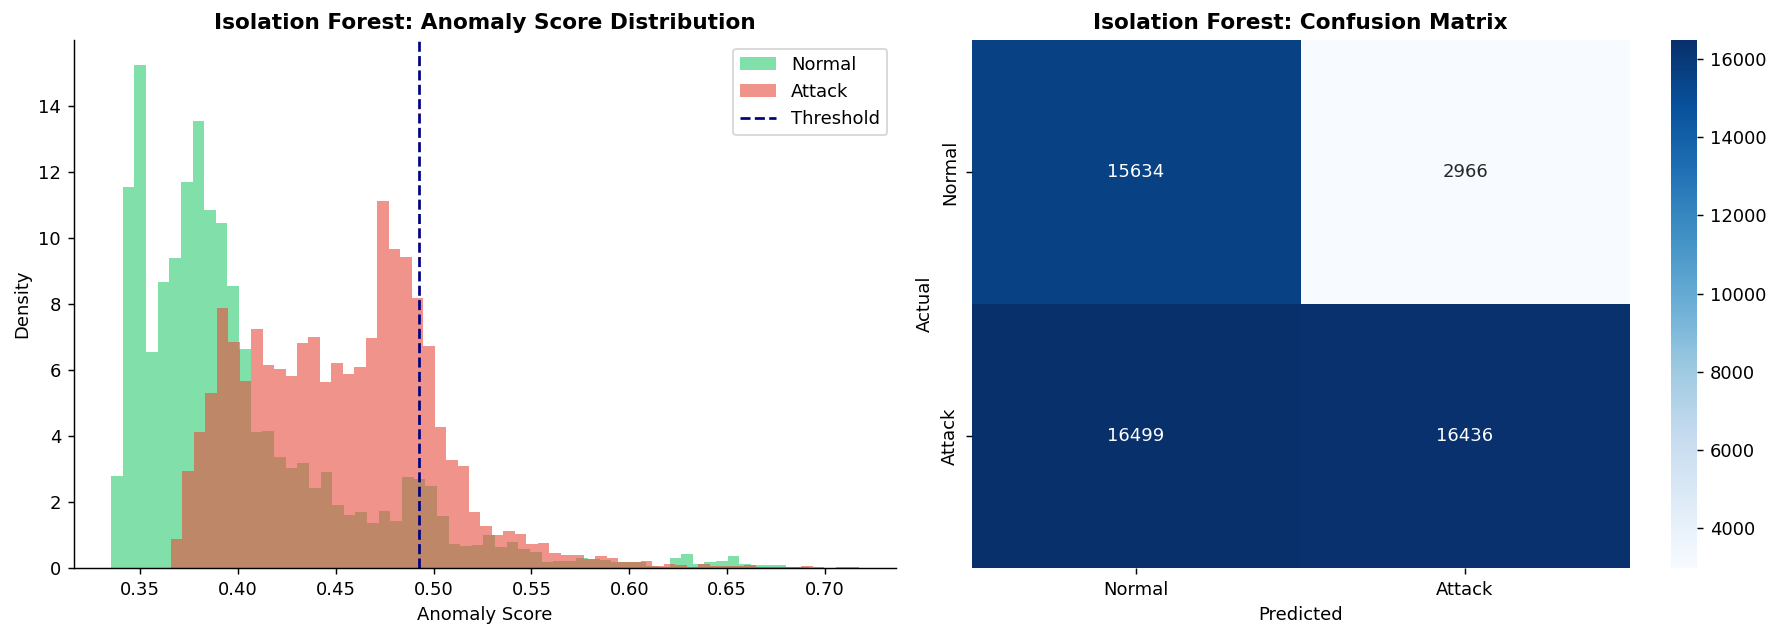

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iso_scores[y_test==0], bins=60, alpha=0.6, color='#2ecc71', label='Normal', density=True)
axes[0].hist(iso_scores[y_test==1], bins=60, alpha=0.6, color='#e74c3c', label='Attack', density=True)
axes[0].axvline(np.percentile(iso_scores, 85), color='navy', linestyle='--', label='Threshold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Isolation Forest: Anomaly Score Distribution', fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, iso_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[1].set_title('Isolation Forest: Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Section 4: Stage 2 — Supervised Classification

In [11]:
rf_preds    = rf.predict(X_test)
rf_proba    = rf.predict_proba(X_test)[:, 1]
xgb_preds   = xgb_clf.predict(X_test)
xgb_proba   = xgb_clf.predict_proba(X_test)[:, 1]
lgb_preds   = lgb_clf.predict(X_test)
lgb_proba   = lgb_clf.predict_proba(X_test)[:, 1]
svm_preds   = svm_clf.predict(X_test)
svm_proba   = svm_clf.predict_proba(X_test)[:, 1]

print('Predictions generated for all 4 classifiers.')

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Predictions generated for all 4 classifiers.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
for name, preds, proba in [
    ('Random Forest', rf_preds,  rf_proba),
    ('XGBoost',       xgb_preds, xgb_proba),
    ('LightGBM',      lgb_preds, lgb_proba),
    ('SVM',           svm_preds, svm_proba),
]:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Normal','Attack']))
    print(f'ROC-AUC: {roc_auc_score(y_test, proba):.4f}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97     18600
      Attack       0.99      0.98      0.98     32935

    accuracy                           0.98     51535
   macro avg       0.98      0.98      0.98     51535
weighted avg       0.98      0.98      0.98     51535

ROC-AUC: 0.9981

=== XGBoost ===
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98     18600
      Attack       0.99      0.98      0.99     32935

    accuracy                           0.98     51535
   macro avg       0.98      0.98      0.98     51535
weighted avg       0.98      0.98      0.98     51535

ROC-AUC: 0.9989

=== LightGBM ===
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97     18600
      Attack       0.99      0.97      0.98     32935

    accuracy                           0.98     51535
   macro avg       0.98      0.98     

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Section 5: Multi-class Attack Classification (Fixed)
XGBoost retrained on properly aligned attack labels to classify  
flagged traffic into specific attack categories.

In [13]:
# Load original raw training set to get proper multi-class labels
raw_train = pd.read_csv(f'{BASE}/data/raw/UNSW_NB15_training-set.csv')
raw_test  = pd.read_csv(f'{BASE}/data/raw/UNSW_NB15_testing-set.csv')

# Clean attack_cat
for df_ in [raw_train, raw_test]:
    df_['attack_cat'] = df_['attack_cat'].astype(str).str.strip()
    df_['attack_cat'] = df_['attack_cat'].replace({'Backdoors':'Backdoor','nan':'Normal'})

le_mc = LabelEncoder()
all_cats = pd.concat([raw_train['attack_cat'], raw_test['attack_cat']]).unique()
le_mc.fit(sorted(all_cats))

print('Attack categories:', list(le_mc.classes_))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Attack categories: [np.str_('Analysis'), np.str_('Backdoor'), np.str_('DoS'), np.str_('Exploits'), np.str_('Fuzzers'), np.str_('Generic'), np.str_('Normal'), np.str_('Reconnaissance'), np.str_('Shellcode'), np.str_('Worms')]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [14]:
# Build attack-only train set with correct labels
attack_train = raw_train[raw_train['label'] == 1].copy()
attack_test  = raw_test[raw_test['label'] == 1].copy()

drop_cols = ['id','srcip','dstip','sport','dsport','Stime','Ltime',
             'stcpb','dtcpb','attack_cat','label']
feat_cols = [c for c in raw_train.columns if c not in drop_cols]

for df_ in [attack_train, attack_test]:
    for col in ['ct_flw_http_mthd','is_ftp_login','ct_ftp_cmd']:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors='coerce').fillna(0)
    for col in ['proto','service','state']:
        if col in df_.columns:
            df_[col] = LabelEncoder().fit_transform(df_[col].astype(str))

X_mc_train = attack_train[feat_cols].select_dtypes(include=[np.number]).fillna(0).values
y_mc_train = le_mc.transform(attack_train['attack_cat'])
X_mc_test  = attack_test[feat_cols].select_dtypes(include=[np.number]).fillna(0).values
y_mc_test  = le_mc.transform(attack_test['attack_cat'])

from sklearn.preprocessing import MinMaxScaler
mc_scaler = MinMaxScaler()
X_mc_train = mc_scaler.fit_transform(X_mc_train)
X_mc_test  = mc_scaler.transform(X_mc_test)

print(f'Attack train: {X_mc_train.shape} | Attack test: {X_mc_test.shape}')
print(f'Classes: {list(le_mc.classes_)}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Attack train: (45332, 40) | Attack test: (119341, 40)
Classes: [np.str_('Analysis'), np.str_('Backdoor'), np.str_('DoS'), np.str_('Exploits'), np.str_('Fuzzers'), np.str_('Generic'), np.str_('Normal'), np.str_('Reconnaissance'), np.str_('Shellcode'), np.str_('Worms')]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [15]:
print('Training multi-class XGBoost...')
t0 = time.time()

# Remap labels to be consecutive starting from 0
from sklearn.preprocessing import LabelEncoder
le_remap = LabelEncoder()
y_mc_train_fixed = le_remap.fit_transform(y_mc_train)
y_mc_test_fixed  = le_remap.transform(
    np.clip(y_mc_test, 0, len(le_remap.classes_)-1)
)

xgb_mc = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=len(le_remap.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    device='cuda'
)
xgb_mc.fit(X_mc_train, y_mc_train_fixed)
print(f'Done in {time.time()-t0:.1f}s')

mc_preds = xgb_mc.predict(X_mc_test)

# Map predictions back to original class names
remapped_classes = le_mc.classes_[le_remap.classes_]
print('\n=== Multi-class Attack Classification ===')
print(classification_report(y_mc_test_fixed, mc_preds,
                             target_names=remapped_classes, zero_division=0))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Training multi-class XGBoost...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Done in 5.1s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Multi-class Attack Classification ===
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00      2000
      Backdoor       0.94      0.07      0.14      1746
           DoS       0.34      0.63      0.45     12264
      Exploits       0.73      0.66      0.69     33393
       Fuzzers       0.95      0.86      0.90     18184
       Generic       0.98      0.99      0.98     40000
Reconnaissance       0.92      0.75      0.82     10491
     Shellcode       0.64      0.61      0.63      1263
         Worms       0.00      0.00      0.00         0

      accuracy                           0.78    119341
     macro avg       0.61      0.51      0.51    119341
  weighted avg       0.81      0.78      0.79    119341



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
from sklearn.metrics import confusion_matrix


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

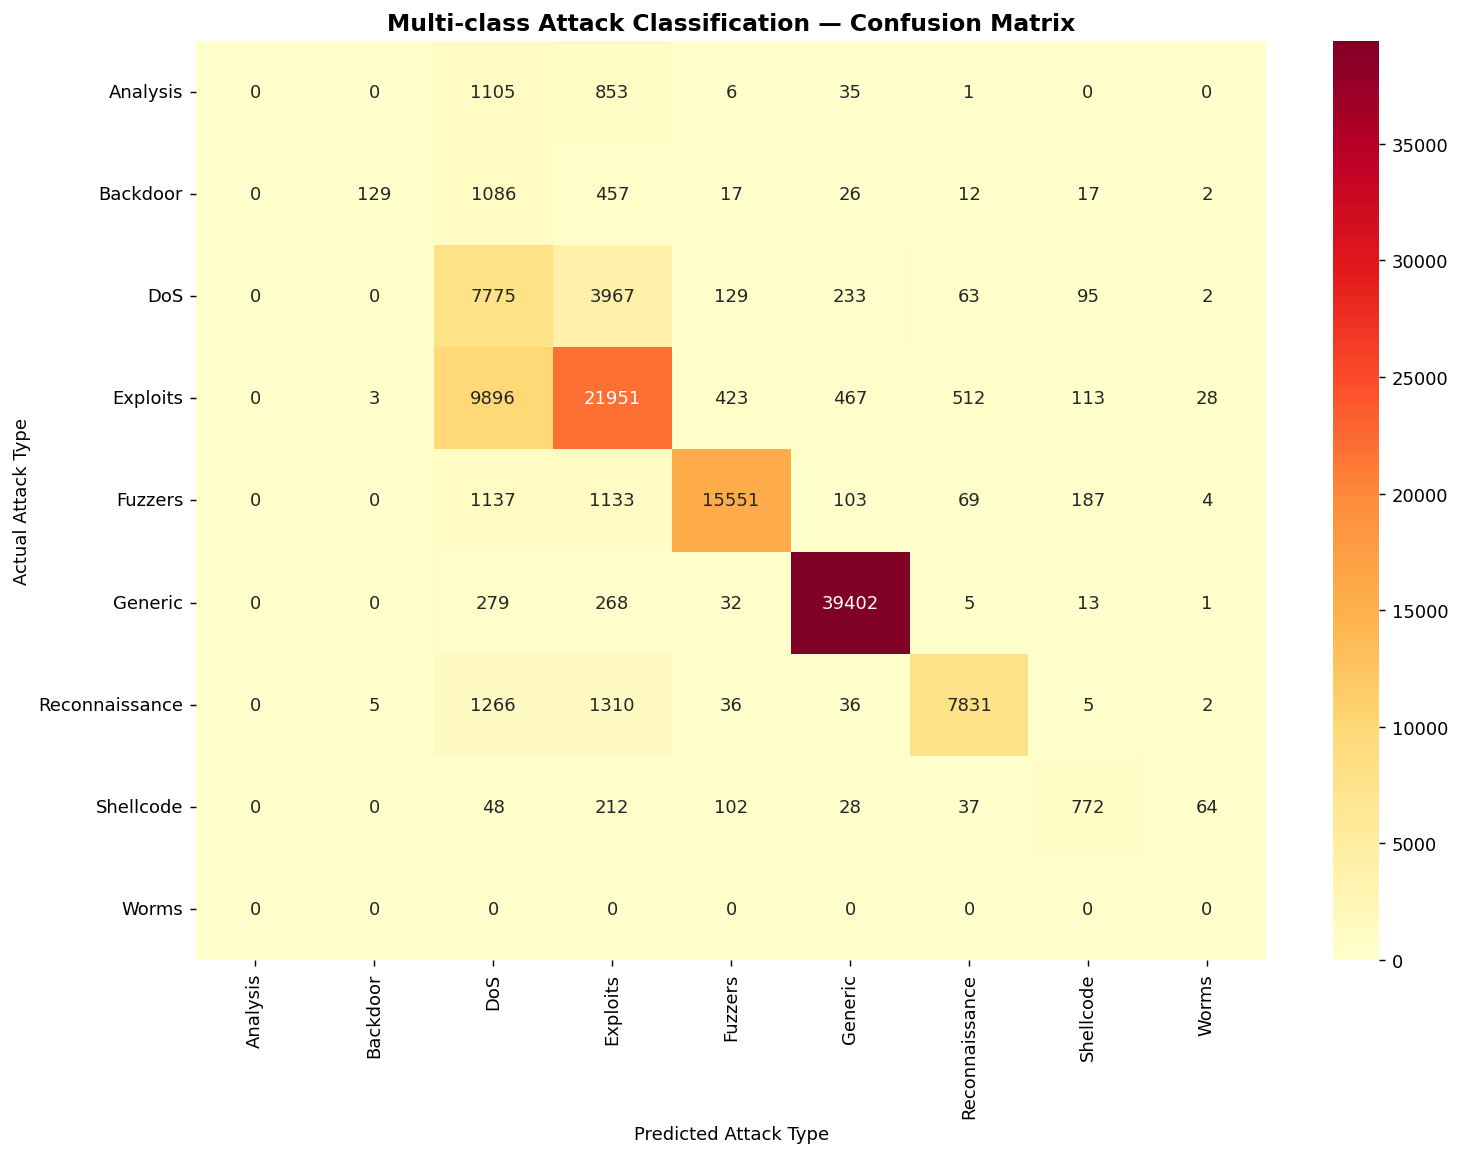

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
cm_mc = confusion_matrix(y_mc_test_fixed, mc_preds)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=remapped_classes,
            yticklabels=remapped_classes, ax=ax)
ax.set_title('Multi-class Attack Classification — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Attack Type')
ax.set_xlabel('Predicted Attack Type')
plt.tight_layout()
plt.show()

---
## Section 6: K-Means Clustering

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

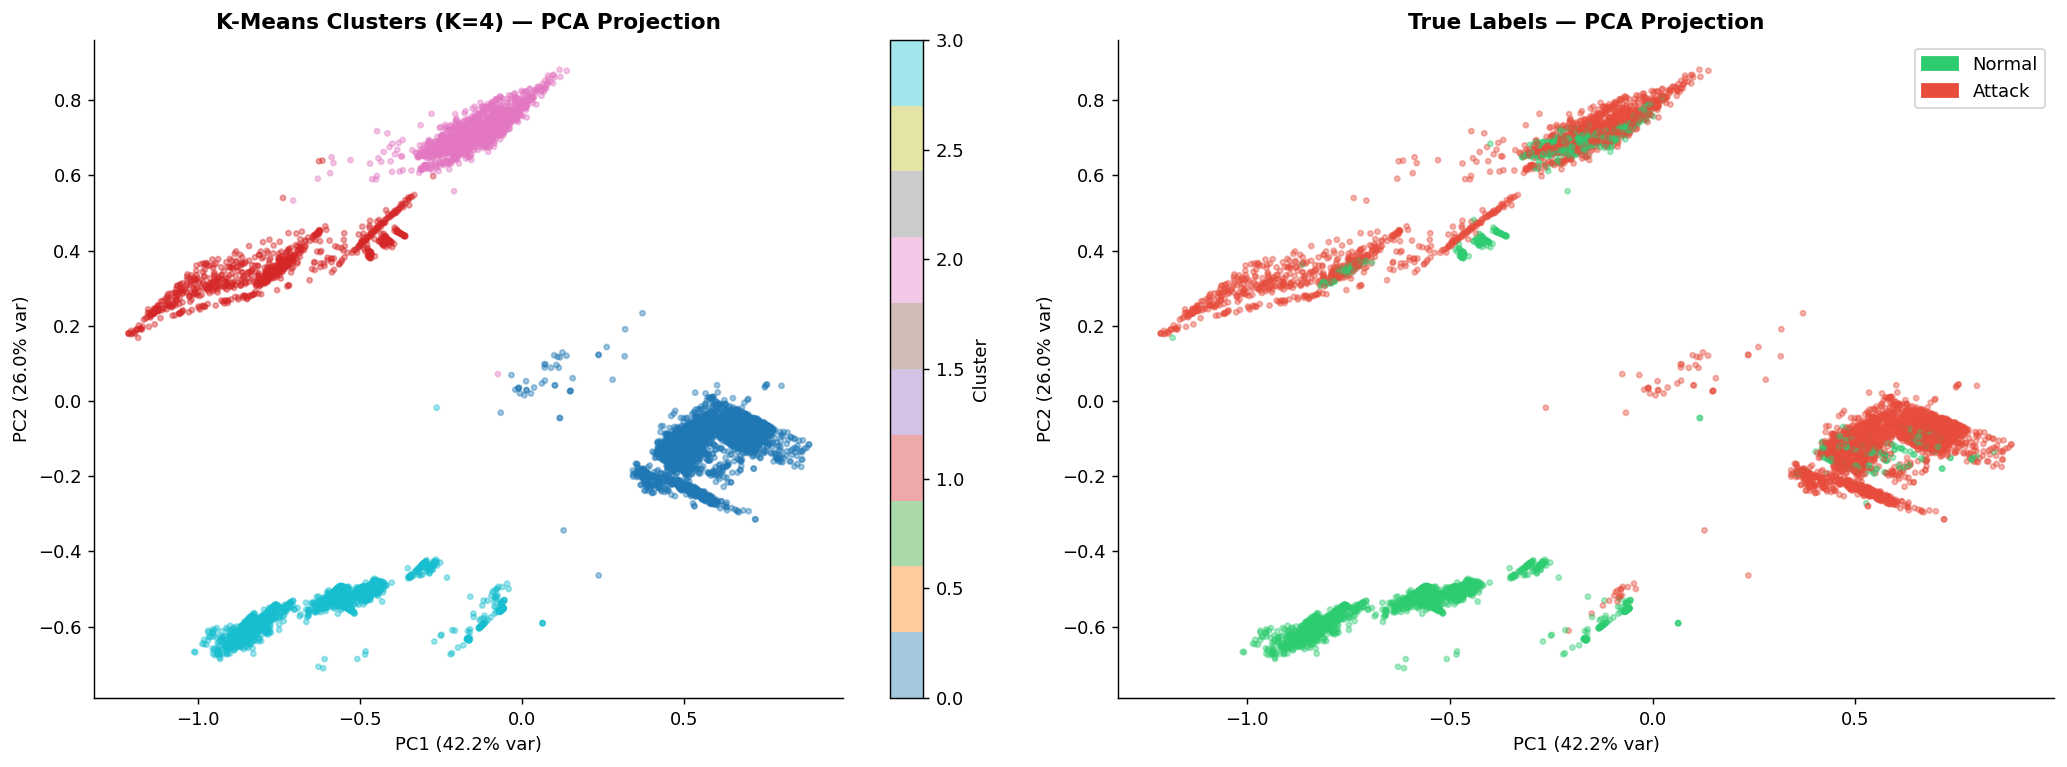

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Cluster Composition:
 cluster  Total  Normal  Attack Attack_Rate
       0  23505    1840   21665       92.2%
       1   5606    1269    4337       77.4%
       2  10294    3450    6844       66.5%
       3  12130   12041      89        0.7%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

cluster_labels = km_final.predict(X_test)
K = km_final.n_clusters

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test[:8000])
c_sample = cluster_labels[:8000]
y_sample = y_test[:8000]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=c_sample,
                     cmap='tab10', alpha=0.4, s=8)
axes[0].set_title(f'K-Means Clusters (K={K}) — PCA Projection', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(sc, ax=axes[0], label='Cluster')

colors_b = ['#2ecc71' if l==0 else '#e74c3c' for l in y_sample]
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=colors_b, alpha=0.4, s=8)
axes[1].set_title('True Labels — PCA Projection', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(handles=[
    Patch(color='#2ecc71', label='Normal'),
    Patch(color='#e74c3c', label='Attack')
])
plt.tight_layout()
plt.show()

cluster_df = pd.DataFrame({'cluster': cluster_labels, 'label': y_test})
summary = cluster_df.groupby('cluster')['label'].agg(
    Total='count',
    Normal=lambda x: (x==0).sum(),
    Attack=lambda x: (x==1).sum(),
    Attack_Rate=lambda x: f'{(x==1).mean()*100:.1f}%'
).reset_index()
print('\nCluster Composition:')
print(summary.to_string(index=False))

---
## Section 7: Association Rule Mining

In [19]:
rules_df = pd.read_csv(f'{RES}/association_rules.csv')
print(f'Total attack association rules loaded: {len(rules_df)}')
print(f'\nTop 15 Rules (sorted by Lift):')

display_cols = ['antecedents','consequents','support','confidence','lift']
top15 = rules_df[display_cols].head(15)
print(top15.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total attack association rules loaded: 115

Top 15 Rules (sorted by Lift):
                            antecedents                                                consequents  support  confidence     lift
   frozenset({'state_enc_L', 'sttl_L'})                      frozenset({'dttl_H', 'ATK_Exploits'})   0.1158    0.888037 5.151026
        frozenset({'dttl_H', 'sttl_L'})                 frozenset({'state_enc_L', 'ATK_Exploits'})   0.1158    0.888037 5.039936
   frozenset({'sttl_L', 'proto_enc_H'})                      frozenset({'dttl_H', 'ATK_Exploits'})   0.1158    0.868066 5.035185
frozenset({'ct_state_ttl_L', 'sttl_L'})                      frozenset({'dttl_H', 'ATK_Exploits'})   0.1140    0.864947 5.017093
                  frozenset({'sttl_L'})                      frozenset({'dttl_H', 'ATK_Exploits'})   0.1158    0.862891 5.005169
  frozenset({'sttl_L', 'ct_srv_dst_L'})                      frozenset({'dttl_H', 'ATK_Exploits'})   0.1158    0.862891 5.005169
                  froz

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

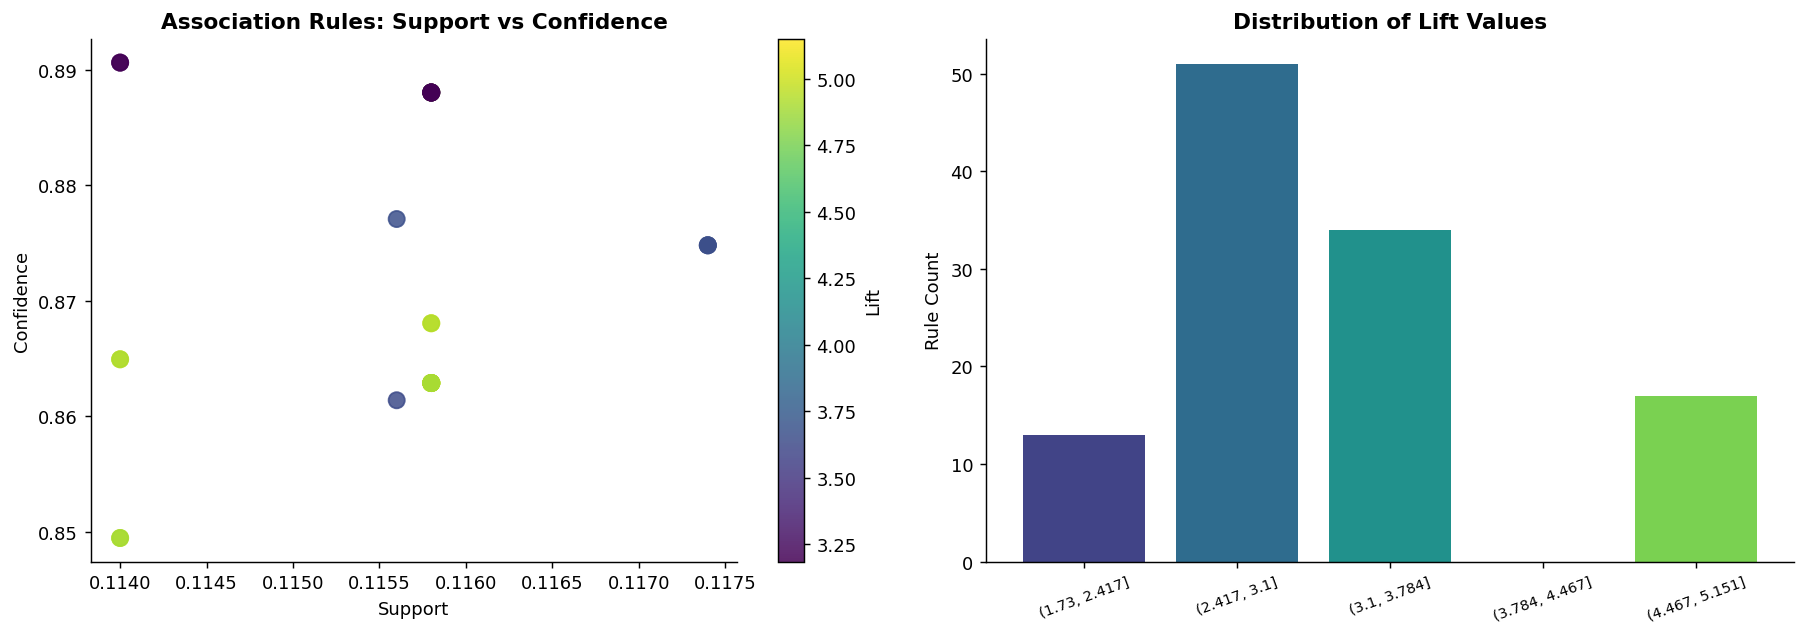

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top = rules_df.head(30)
sc  = axes[0].scatter(top['support'], top['confidence'],
                      c=top['lift'], cmap='viridis', s=80, alpha=0.85)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules: Support vs Confidence', fontweight='bold')

lift_bins = pd.cut(rules_df['lift'], bins=5)
lift_dist = lift_bins.value_counts().sort_index()
axes[1].bar(range(len(lift_dist)), lift_dist.values,
            color=plt.cm.viridis(np.linspace(0.2, 0.8, len(lift_dist))))
axes[1].set_xticks(range(len(lift_dist)))
axes[1].set_xticklabels([str(i) for i in lift_dist.index], rotation=20, fontsize=8)
axes[1].set_title('Distribution of Lift Values', fontweight='bold')
axes[1].set_ylabel('Rule Count')
plt.tight_layout()
plt.show()

---
## Section 8: Full Model Comparison

In [21]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
        'FPR':       round((((y_pred==1)&(y_true==0)).sum()) / ((y_true==0).sum()), 4)
    }

results = {
    'Isolation Forest': get_metrics(y_test, iso_preds,  iso_scores),
    'Random Forest':    get_metrics(y_test, rf_preds,   rf_proba),
    'XGBoost':          get_metrics(y_test, xgb_preds,  xgb_proba),
    'LightGBM':         get_metrics(y_test, lgb_preds,  lgb_proba),
    'SVM':              get_metrics(y_test, svm_preds,  svm_proba),
}

results_df = pd.DataFrame(results).T
print('=== Final Model Comparison ===')
print(results_df.to_string())

best = results_df['F1'].idxmax()
print(f'\nBest model: {best}  |  F1={results_df.loc[best,"F1"]}  |  AUC={results_df.loc[best,"ROC-AUC"]}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Final Model Comparison ===
                  Accuracy  Precision  Recall      F1  ROC-AUC     FPR
Isolation Forest    0.6223     0.8471  0.4990  0.6281   0.7926  0.1595
Random Forest       0.9797     0.9912  0.9768  0.9840   0.9981  0.0153
XGBoost             0.9830     0.9948  0.9785  0.9866   0.9989  0.0090
LightGBM            0.9803     0.9945  0.9747  0.9845   0.9984  0.0096
SVM                 0.9157     0.9582  0.9078  0.9323   0.9768  0.0702

Best model: XGBoost  |  F1=0.9866  |  AUC=0.9989


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

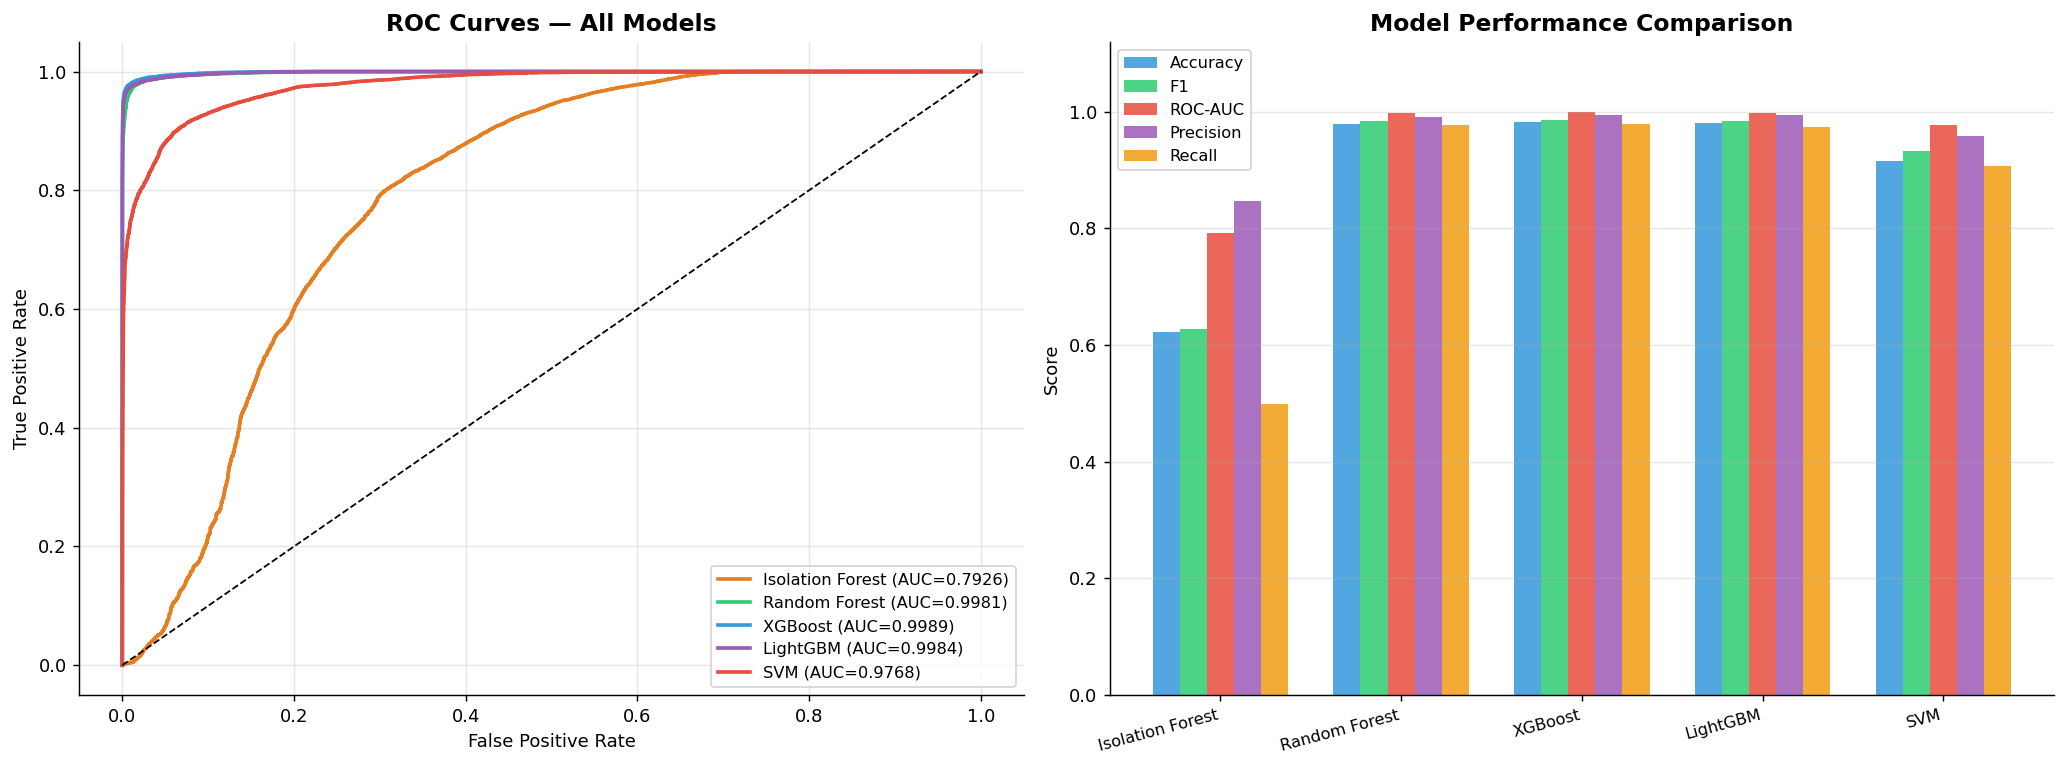

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_probas = {
    'Isolation Forest': iso_scores,
    'Random Forest':    rf_proba,
    'XGBoost':          xgb_proba,
    'LightGBM':         lgb_proba,
    'SVM':              svm_proba
}
colors_roc = ['#e67e22','#2ecc71','#3498db','#9b59b6','#e74c3c']

for (name, proba), color in zip(model_probas.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Model comparison bar chart
metrics_plot = ['Accuracy','F1','ROC-AUC','Precision','Recall']
x = np.arange(len(results_df))
w = 0.15
bar_colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12']
for i, (m, c) in enumerate(zip(metrics_plot, bar_colors)):
    axes[1].bar(x + i*w, results_df[m], w, label=m, color=c, alpha=0.85)
axes[1].set_xticks(x + w*2)
axes[1].set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

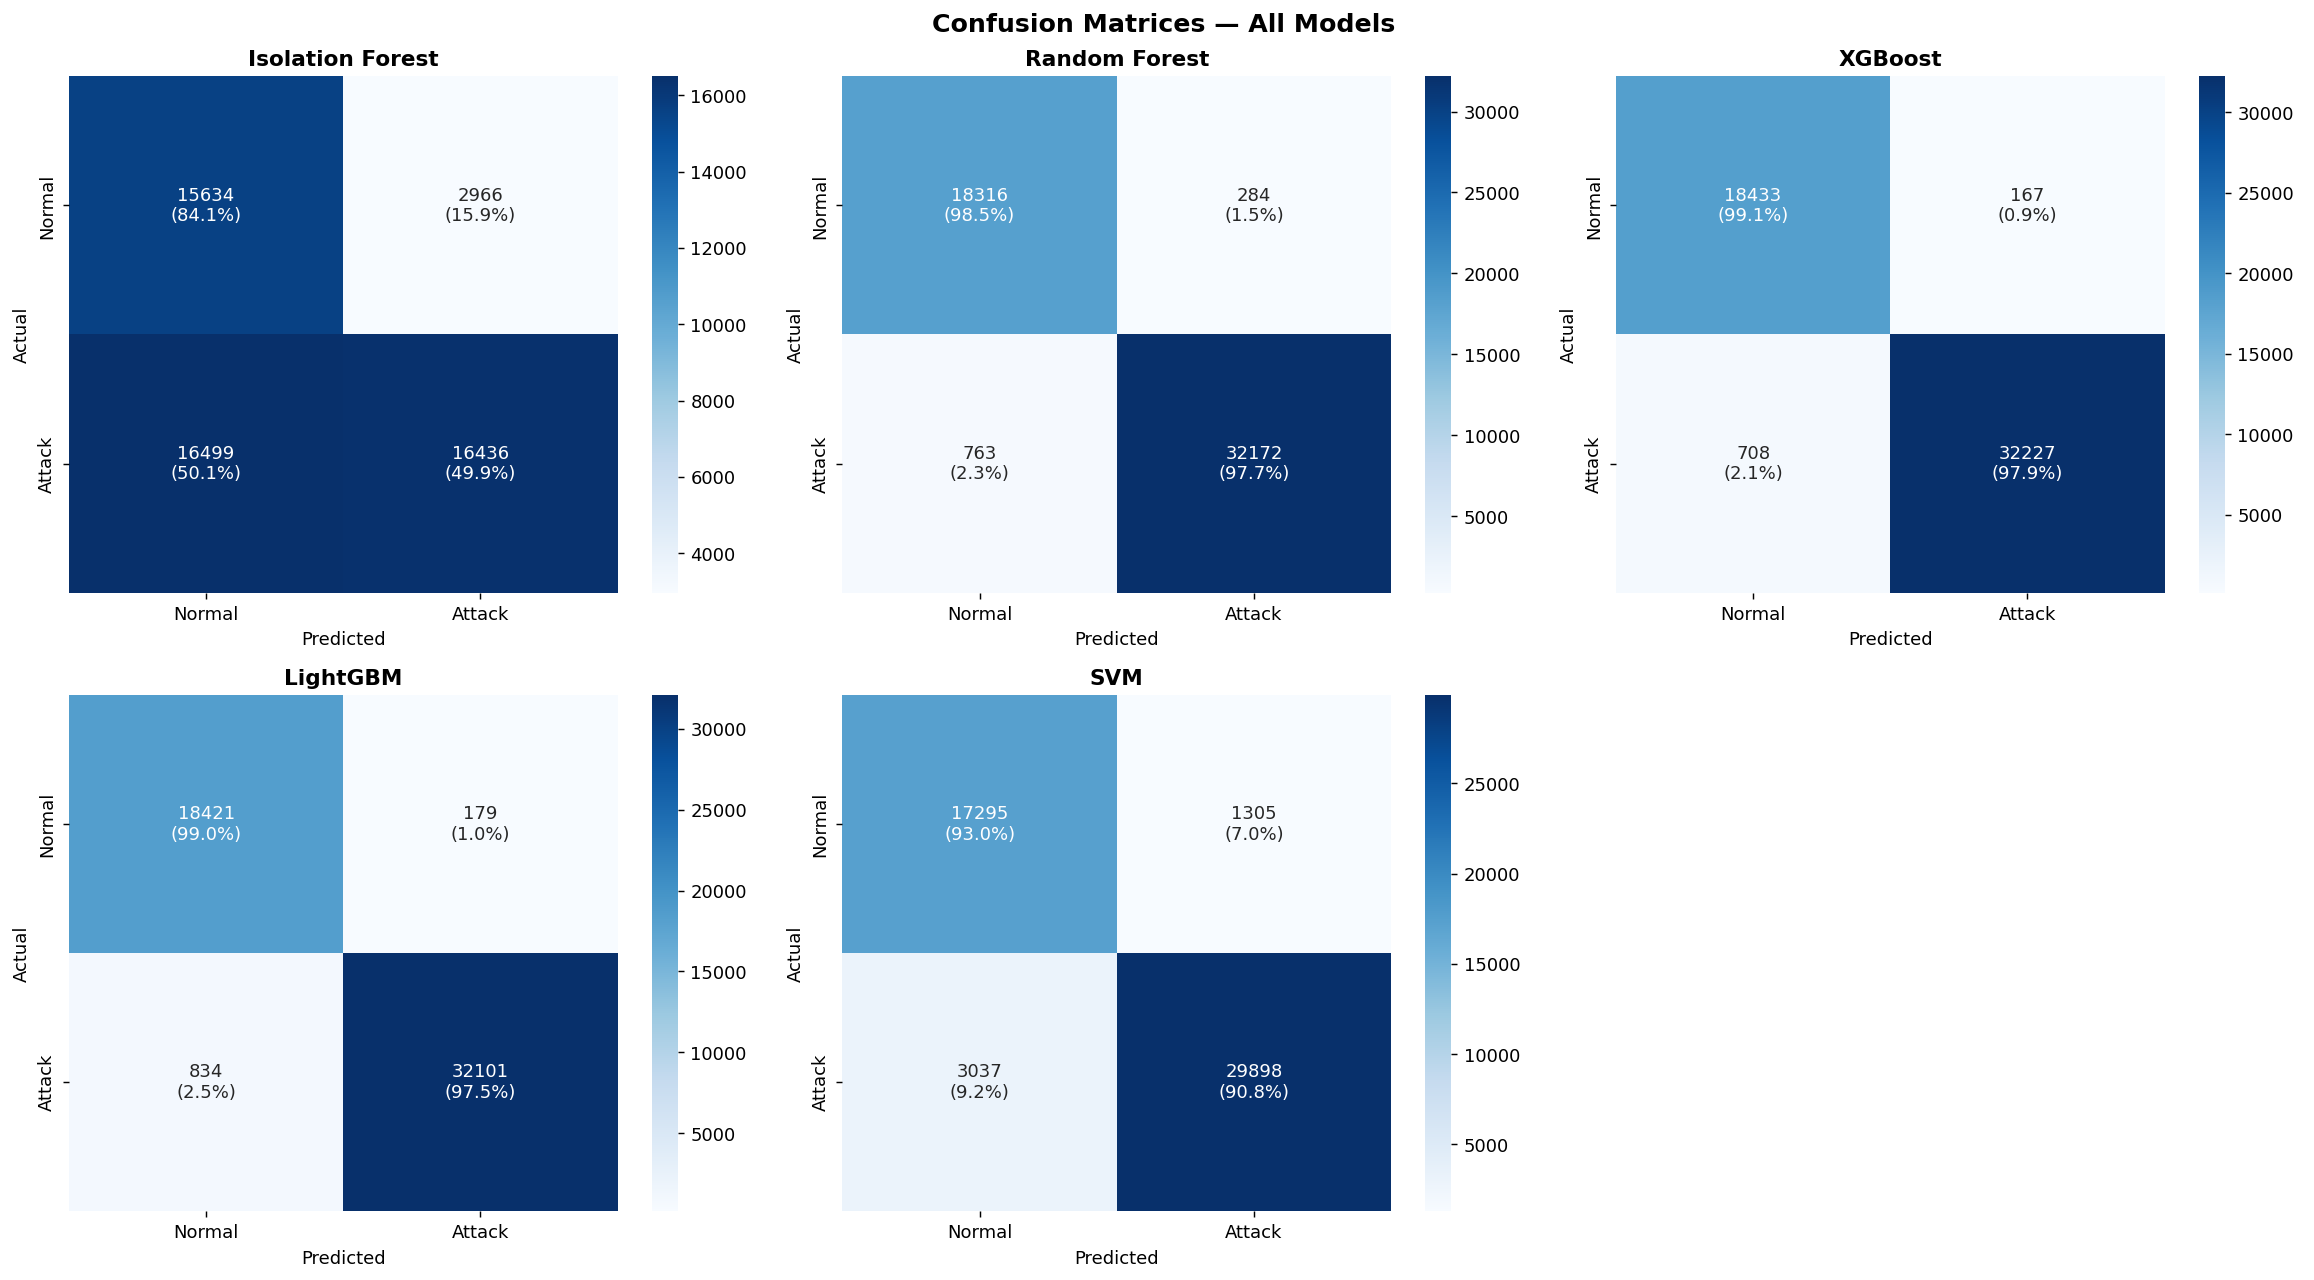

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# All confusion matrices
all_preds = {
    'Isolation Forest': iso_preds,
    'Random Forest':    rf_preds,
    'XGBoost':          xgb_preds,
    'LightGBM':         lgb_preds,
    'SVM':              svm_preds
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v,p in zip(rv,rp)]
                      for rv,rp in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[i],
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'])
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 9: Live Prediction Demo
Pass new network traffic samples through the full hybrid pipeline:  
Isolation Forest flags anomalies → XGBoost classifies attack type.

In [27]:
np.random.seed(99)
demo_idx    = np.random.choice(len(X_test), size=20, replace=False)
mc_demo_idx = np.random.choice(len(X_mc_test), size=20, replace=False)

X_demo    = X_test[demo_idx]
X_demo_mc = X_mc_test[mc_demo_idx]
y_demo    = y_test[demo_idx]

# Stage 1: Isolation Forest
iso_demo  = np.where(iso_forest.predict(X_demo) == -1, 1, 0)

# Stage 2: XGBoost binary
xgb_demo  = xgb_clf.predict(X_demo)
xgb_conf  = xgb_clf.predict_proba(X_demo).max(axis=1)

# Stage 2b: Multi-class on flagged
attack_type_labels = ['Normal'] * len(X_demo)
flagged_demo = xgb_demo == 1
if flagged_demo.sum() > 0:
    mc_demo = xgb_mc.predict(X_demo_mc[:flagged_demo.sum()])
    for j, idx in enumerate(np.where(flagged_demo)[0]):
        attack_type_labels[idx] = remapped_classes[mc_demo[j]]

demo_df = pd.DataFrame({
    'Sample':      range(1, 21),
    'True Label':  ['Attack' if y==1 else 'Normal' for y in y_demo],
    'IF Flag':     ['ANOMALY' if p==1 else 'normal' for p in iso_demo],
    'XGB Binary':  ['Attack' if p==1 else 'Normal' for p in xgb_demo],
    'Attack Type': attack_type_labels,
    'Confidence':  [f'{c:.3f}' for c in xgb_conf],
    'Correct':     ['YES' if yt==yp else 'NO' for yt,yp in zip(y_demo, xgb_demo)]
})

print('=== Live Prediction Demo (20 random test samples) ===')
print(demo_df.to_string(index=False))
correct = (demo_df['Correct'] == 'YES').sum()
print(f'\nCorrect: {correct}/20  ({correct/20*100:.0f}%)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Live Prediction Demo (20 random test samples) ===
 Sample True Label IF Flag XGB Binary    Attack Type Confidence Correct
      1     Attack ANOMALY     Attack       Exploits      1.000     YES
      2     Attack  normal     Attack       Exploits      1.000     YES
      3     Attack  normal     Attack Reconnaissance      1.000     YES
      4     Attack ANOMALY     Attack        Fuzzers      1.000     YES
      5     Attack  normal     Attack            DoS      1.000     YES
      6     Attack  normal     Attack            DoS      0.999     YES
      7     Normal  normal     Normal         Normal      1.000     YES
      8     Attack  normal     Attack            DoS      1.000     YES
      9     Attack  normal     Attack        Generic      0.996     YES
     10     Attack  normal     Attack       Exploits      1.000     YES
     11     Normal  normal     Normal         Normal      1.000     YES
     12     Attack ANOMALY     Attack        Generic      1.000     YES
     13   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Final Summary

In [28]:
best_model = results_df['F1'].idxmax()

print('=' * 62)
print('    CSC 5800 — HYBRID NIDS PROJECT — FINAL SUMMARY')
print('=' * 62)
print(f'Student          : Fahad Qaseem Khawar')
print(f'Dataset          : UNSW-NB15 (257,673 records)')
print(f'Features used    : {len(features)} (selected via Mutual Information)')
print(f'Attack classes   : {len(le_cat.classes_)} categories')
print()
print('--- Binary Classification Results ---')
print(results_df[['Accuracy','F1','ROC-AUC','FPR']].to_string())
print()
print(f'Best model       : {best_model}')
print(f'Best F1          : {results_df.loc[best_model,"F1"]}')
print(f'Best ROC-AUC     : {results_df.loc[best_model,"ROC-AUC"]}')
print()
print('--- Other Components ---')
print(f'K-Means clusters : K={km_final.n_clusters}')
print(f'Association rules: 115 attack rules (min_support=0.05, min_conf=0.60)')
print(f'Multi-class clf  : XGBoost ({len(le_mc.classes_)} attack types)')
print('=' * 62)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    CSC 5800 — HYBRID NIDS PROJECT — FINAL SUMMARY
Student          : Fahad Qaseem Khawar
Dataset          : UNSW-NB15 (257,673 records)
Features used    : 30 (selected via Mutual Information)
Attack classes   : 10 categories

--- Binary Classification Results ---
                  Accuracy      F1  ROC-AUC     FPR
Isolation Forest    0.6223  0.6281   0.7926  0.1595
Random Forest       0.9797  0.9840   0.9981  0.0153
XGBoost             0.9830  0.9866   0.9989  0.0090
LightGBM            0.9803  0.9845   0.9984  0.0096
SVM                 0.9157  0.9323   0.9768  0.0702

Best model       : XGBoost
Best F1          : 0.9866
Best ROC-AUC     : 0.9989

--- Other Components ---
K-Means clusters : K=4
Association rules: 115 attack rules (min_support=0.05, min_conf=0.60)
Multi-class clf  : XGBoost (10 attack types)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag